In [ ]:
## Aula 3: Do catálogo ao espectro de potência angular
# Isabela, Louis, Bruno

In [6]:
# Importing python packages

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import glass.shells
import glass.fields
import glass.points
import glass.galaxies
import glass.lensing
import glass.observations
import glass.ext.camb
from cosmology.compat.camb import Cosmology
#import pymaster as nmt
import healpy as hp
import camb
import os
import warnings


rcParams['font.size'] = 14
rcParams['axes.labelsize'] = 14
rcParams['xtick.labelsize'] = 14
rcParams['ytick.labelsize'] = 14

## 1. Gerando um catálogo de galáxias

Colocar aqui alguma explicacao sobre simulacoes lognormais

### 1.a) Calculando o espectro de potência angular da matéria

In [8]:
# Onde salvar os arquivos de saída
storage = "../data/aula_3" # modificar para o caminho correto
matter_cls_dir = storage+'/matter_cls'
os.makedirs(os.path.dirname(f'{matter_cls_dir}/cls.npy'), exist_ok=True)
    
# Parâmetros da simulação
lmax = 300
zmax = 1
dz = 0.2

# Parâmetros cosmológicos (Planck 2018)
H0 = 67.36
omch2 = 0.1225
ombh2 = 0.0223
As = 2.2e-9
ns = 0.96
tau = 0.06

pars = camb.set_params(H0=H0, omch2=omch2, ombh2=ombh2,
                        As=As, ns=ns, tau=tau,
                        NonLinear=camb.model.NonLinear_both)

# Cascas de redshift
zb = glass.shells.redshift_grid(0., zmax, dz=dz)

# Função janela (top-hat)
ws = glass.shells.tophat_windows(zb, dz=dz/100)

# Calculando o espectro de potência angular da matéria com CAMB
cls = glass.ext.camb.matter_cls(pars, lmax, ws)
np.save(f'{matter_cls_dir}/cls', cls) # matriz com Nmultipoles*Nzbins*(Nzbins+1)/2 elementos


Adicionar aqui plot dos Cls da materia (talvez plot 3D?)

### 1.b) Criando galáxias

In [9]:
# Calculando o espectro de potência do campo Gaussiano correspondente

# Resolução do mapa pixelizado
nside = 128
# Número de casacas de redshift cuja correlação será considerada (corr=None: todas as casacas são correlacionadas)
corr = None

# Número de bins de redshift e valor médio de cada bin
Nbins = len(zb)-1
zbar = (zb[1:]+zb[:-1])/2

# Load Cls da matéria
cls = np.load(matter_cls_dir+'/cls.npy')

# Definindo os campos lognormais
fields = glass.lognormal_fields(ws)

# Calculando os Cls Gaussianos    
Cls = glass.discretized_cls(cls, nside=nside, lmax=lmax, ncorr=corr)
gls = glass.solve_gaussian_spectra(fields, Cls)

# Salvando os Cls Gaussianos
os.makedirs(os.path.dirname(f'{matter_cls_dir}/gls.npy'), exist_ok=True)
arr = np.array(gls, dtype=object)
np.save(f'{matter_cls_dir}/gls', arr, allow_pickle=True)


Aqui podemos ter como exercicio calular a funcao de correlacao angular C(theta) a partir dos Cls e dos Gls para comparacao.

Tambem podemos adicionar propositalmente casos problematicos pra simulacao lognormal, onde algum gl tem diagonal negativa ou o lmax nao é grande o suficiente pra fazer C(theta) ser > -1. Podemos mostrar como contornar esses problemas. Talvez isso seja um pouco tecnico demais (??)

In [10]:
# Onde queremos salvar nosso catálogo de galáxias
gdir = storage+'/galaxy_catalogs'

# Definindo a função de viés de galáxias e a densidade de galáxias por arcmin²

arcmin2_sky = 148510800

def bias_g(z):
  """Galaxy bias"""
  return 0.971 + 1.042*z

def dndz_g(z):
  """Galaxy redshift distribution (# of galaxies per arcmin² per redshift)"""
  return (6*1e7/arcmin2_sky) * glass.observations.smail_nz(z, 0.7, 0.8, 2.) # tuned for desi legacy
           

In [13]:
# Cosmologia
camb_back = camb.get_background(pars)
cosmo = Cosmology(camb_back)

# Load Gls
gls = np.load(f'{matter_cls_dir}/gls.npy', allow_pickle=True)


catalog_G = np.zeros(len(zb)-1, dtype=[('LON', object), ('LAT', object),
                                        ('Z_TRUE', object), ('KAPPA', object)])


# Gerando um campo de matéria lognormal a partir dos Gls
matter = glass.fields.generate_lognormal(gls, nside, ncorr=corr) 

# Calculando a convergência
convergence = glass.lensing.MultiPlaneConvergence(cosmo)

for i, delta_i in enumerate(matter): 

    if i > Nbins-1:
        continue

    zg_i, dndzg_i = glass.shells.restrict(zb, dndz_g(zb), ws[i])  # smail
    ngal = np.trapezoid(dndzg_i, zg_i)

    if ngal*arcmin2_sky < 1:
        warnings.warn(f"Nenhuma galáxia no bin {i}.", category=UserWarning, stacklevel=2)
        continue

    # Salvando a convergência em cada casca de redshift
    #convergence.dd_window(delta_i, ws[i])
    #kappa_i = convergence.kappa
    #catalog_G[i]['KAPPA'] = kappa_i

    # Gerando as posições das galáxias a partir do campo de densidade (ngal + contraste delta, com viés) na casca i
    pos_gal = glass.points.positions_from_delta(ngal, delta_i,bias=glass.points.effective_bias(zb, bias_g(zb), ws[i]), remove_monopole=True)
    # Remover o monopolo assegura que dndz será o que inserimos mas muda o viés efetivo

    # Salvando o catálogo --------------
    result_list = []

    for lon, lat, count in pos_gal:
        # lon e lat são arrays com as posições de cada galáxia que foi amostrada 
        # count é o número total de galáxias amostradas na casca
        result_list.append((lon, lat, count))

    if result_list:
        gal_lons, gal_lats, gal_counts = zip(*result_list)
        gal_lons = np.concatenate(gal_lons)
        gal_lats = np.concatenate(gal_lats)
    
        gal_counts = np.sum(gal_counts)
        gal_z = glass.galaxies.redshifts_from_nz(gal_counts, ws[i].za, ws[i].wa)

    else:
        gal_lons, gal_lats, gal_z = [], [], []
    
    catalog_G[i]['LON'] = gal_lons # deg
    catalog_G[i]['LAT'] = gal_lats # deg
    catalog_G[i]['Z_TRUE'] = gal_z

os.makedirs(os.path.dirname(f'{gdir}/catalog_G.npy'), exist_ok=True)
np.save(f'{gdir}/catalog_G', catalog_G)

/var/folders/80/8jdvtzhn1ll3hd209lpykmyc0000gp/T/ipykernel_69986/2716161952.py:14: DeprecationWarning: use glass.generate() instead
  matter = glass.fields.generate_lognormal(gls, nside, ncorr=corr)
/var/folders/80/8jdvtzhn1ll3hd209lpykmyc0000gp/T/ipykernel_69986/2716161952.py:54: UserWarning: when sampling galaxies, redshifts_from_nz() is often not the function you want. Try redshifts() instead. Use warn=False to suppress this warning.
  gal_z = glass.galaxies.redshifts_from_nz(gal_counts, ws[i].za, ws[i].wa)


Exercício - "randoms": gerar um catálogo de galáxias extra cujos Gls de input são nulos.

Solução

Só trocar logo no início na célula acima:

gls = np.zeros(np.shape(gls))

gdir = gdir+'_rand'

## 2. Obtendo um mapa pixelizado

In [14]:

gal_count_map = np.zeros(shape=(Nbins, hp.nside2npix(nside)))

for i in range(Nbins):

    gal_pix_index  = hp.ang2pix(nside, catalog_G[i]['LON'], catalog_G[i]['LAT'], lonlat=True)
    unique, counts = np.unique(gal_pix_index, return_counts=True)
    gal_count_map[i,unique] = counts # galaxy counts N in each redshift bin i    

os.makedirs(os.path.dirname(f'{gdir}/gal_count_map.npy'), exist_ok=True)

if f'gal_count_map.npy' in os.listdir(gdir):
    warnings.warn(f'Overwritting.', category=UserWarning, stacklevel=2)

np.save(f'{gdir}/gal_count_map.npy', gal_count_map)


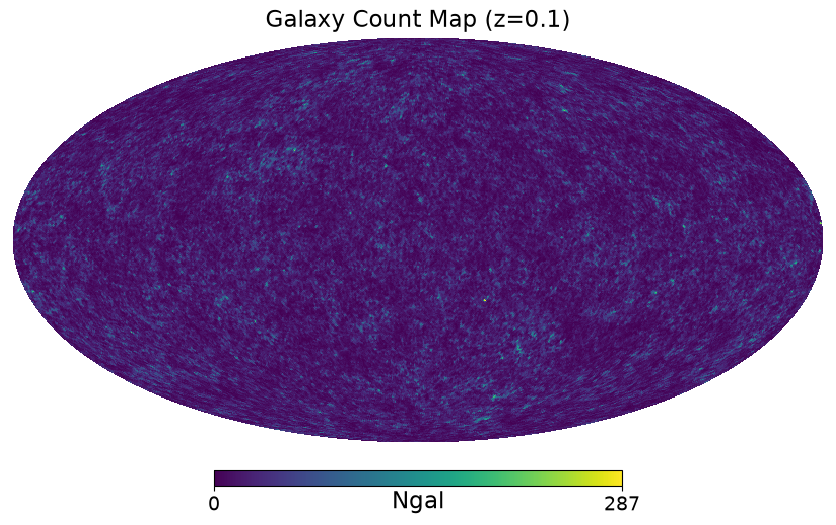

In [15]:
# Visualizando o mapa

hp.mollview(gal_count_map[0], title='Galaxy Count Map (z=0.1)', unit='Ngal', cmap='viridis')

## 3. Calculando o espectro de potência angular